In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report

u_red = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
u_white = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv"

df_r = pd.read_csv(u_red, sep=';')
df_w = pd.read_csv(u_white, sep=';')

print(f"Red Wine Shape: {df_r.shape} | White Wine Shape: {df_w.shape}")
print("\nRed Quality:\n", df_r['quality'].value_counts().sort_index().to_dict())
print("White Quality:\n", df_w['quality'].value_counts().sort_index().to_dict())

Red Wine Shape: (1599, 12) | White Wine Shape: (4898, 12)

Red Quality:
 {3: 10, 4: 53, 5: 681, 6: 638, 7: 199, 8: 18}
White Quality:
 {3: 20, 4: 163, 5: 1457, 6: 2198, 7: 880, 8: 175, 9: 5}


In [18]:
def split(df):
    X = df.drop('quality', axis=1).values
    y = df['quality'].values
    X_tr, X_tmp, y_tr, y_tmp = train_test_split(X, y, test_size=0.3, random_state=42)
    X_va, X_te, y_va, y_te = train_test_split(X_tmp, y_tmp, test_size=0.5, random_state=42)
    return X_tr, X_va, X_te, y_tr, y_va, y_te

# Red data
Xr_tr, Xr_va, Xr_te, yr_tr, yr_va, yr_te = split(df_r)
# White data
Xw_tr, Xw_va, Xw_te, yw_tr, yw_va, yw_te = split(df_w)

print(f"Red: {len(Xr_tr)}/{len(Xr_va)}/{len(Xr_te)}")
print(f"White: {len(Xw_tr)}/{len(Xw_va)}/{len(Xw_te)}")

Red: 1119/240/240
White: 3428/735/735


## Assignment 1:
- Implementing Decision Tree using NumPy.
- Train and evaluate this method on the [Wine Quality](https://archive.ics.uci.edu/dataset/186/wine+quality) dataset using F1 score.


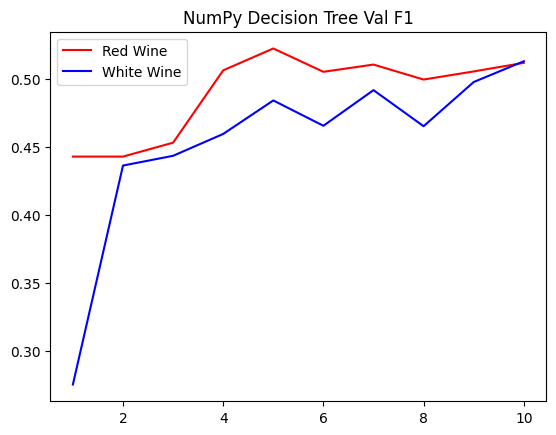

NP Decision Tree Test F1 - Red: 0.5746
NP Decision Tree Test F1 - White: 0.5278


In [19]:
class DT:
    def __init__(self, d=0, md=5):
        self.d, self.md = d, md
        self.l, self.r, self.f, self.th, self.v = [None]*5

    def _g(self, y):
        if len(y) == 0: return 0
        p = np.bincount(y) / len(y)
        return 1 - np.sum(p**2)

    def fit(self, X, y):
        if len(np.unique(y)) == 1 or self.d == self.md:
            self.v = np.bincount(y).argmax()
            return
        m, n = X.shape
        be = 1e9
        for i in range(n):
            for t in np.unique(X[:, i]):
                idx = X[:, i] < t
                if not any(idx) or not any(~idx): continue
                g = (len(y[idx])*self._g(y[idx]) + len(y[~idx])*self._g(y[~idx]))/m
                if g < be: be, self.f, self.th = g, i, t
        if self.f is None:
            self.v = np.bincount(y).argmax(); return
        self.l, self.r = DT(self.d+1, self.md), DT(self.d+1, self.md)
        self.l.fit(X[X[:, self.f] < self.th], y[X[:, self.f] < self.th])
        self.r.fit(X[X[:, self.f] >= self.th], y[X[:, self.f] >= self.th])

    def predict(self, X):
        if self.v is not None: return np.full(len(X), self.v)
        idx = X[:, self.f] < self.th
        p = np.zeros(len(X)); p[idx], p[~idx] = self.l.predict(X[idx]), self.r.predict(X[~idx])
        return p

# Training & Plotting
ds = range(1, 11)
f1_r, f1_w = [], []
for d in ds:
    mr = DT(md=d); mr.fit(Xr_tr, yr_tr); f1_r.append(f1_score(yr_va, mr.predict(Xr_va), average='weighted'))
    mw = DT(md=d); mw.fit(Xw_tr, yw_tr); f1_w.append(f1_score(yw_va, mw.predict(Xw_va), average='weighted'))

plt.plot(ds, f1_r, color='red', label='Red Wine'); plt.plot(ds, f1_w, color='blue', label='White Wine')
plt.title("NumPy Decision Tree Val F1"); plt.legend(); plt.show()

# Final Test
dt_r = DT(md=5); dt_r.fit(Xr_tr, yr_tr); pr_dt = dt_r.predict(Xr_te)
dt_w = DT(md=5); dt_w.fit(Xw_tr, yw_tr); pw_dt = dt_w.predict(Xw_te)
print(f"NP Decision Tree Test F1 - Red: {f1_score(yr_te, pr_dt, average='weighted'):.4f}")
print(f"NP Decision Tree Test F1 - White: {f1_score(yw_te, pw_dt, average='weighted'):.4f}")

## Assignment 2:
- Implementing Random Forest using NumPy.
- Train and evaluate this method on the [Wine Quality](https://archive.ics.uci.edu/dataset/186/wine+quality) dataset using F1 score.

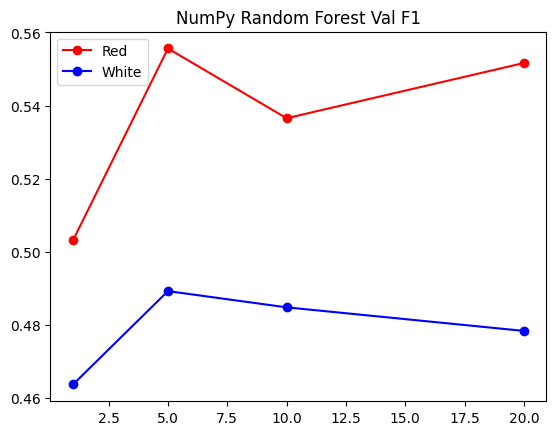

NP Random Forest Test F1 - Red: 0.5839
NP Random Forest Test F1 - White: 0.5606


In [20]:
class RF:
    def __init__(self, nt=10, md=5):
        self.nt, self.md, self.ts = nt, md, []

    def fit(self, X, y):
        for _ in range(self.nt):
            idx = np.random.choice(len(X), len(X), replace=True)
            t = DT(md=self.md); t.fit(X[idx], y[idx]); self.ts.append(t)

    def predict(self, X):
        ps = np.array([t.predict(X) for t in self.ts])
        return np.array([np.bincount(ps[:, i].astype(int)).argmax() for i in range(len(X))])

# Training & Plotting
ns = [1, 5, 10, 20]
rf1_r, rf1_w = [], []
for n in ns:
    mr = RF(nt=n); mr.fit(Xr_tr, yr_tr); rf1_r.append(f1_score(yr_va, mr.predict(Xr_va), average='weighted'))
    mw = RF(nt=n); mw.fit(Xw_tr, yw_tr); rf1_w.append(f1_score(yw_va, mw.predict(Xw_va), average='weighted'))

plt.plot(ns, rf1_r, color='red', marker='o', label='Red'); plt.plot(ns, rf1_w, color='blue', marker='o', label='White')
plt.title("NumPy Random Forest Val F1"); plt.legend(); plt.show()

# Final Test
rf_r = RF(nt=15, md=7); rf_r.fit(Xr_tr, yr_tr); pr_rf = rf_r.predict(Xr_te)
rf_w = RF(nt=15, md=7); rf_w.fit(Xw_tr, yw_tr); pw_rf = rf_w.predict(Xw_te)
print(f"NP Random Forest Test F1 - Red: {f1_score(yr_te, pr_rf, average='weighted'):.4f}")
print(f"NP Random Forest Test F1 - White: {f1_score(yw_te, pw_rf, average='weighted'):.4f}")

## Assignment 3:
- Train and evaluate the Decision Tree method using a machine learning library.
- Train and evaluate the Random Forest method using a machine learning library.

NumPy Decision Tree F1: 0.5746
NumPy Random Forest F1: 0.6168
Library Decision Tree F1: 0.5746
Library Random Forest F1: 0.5673


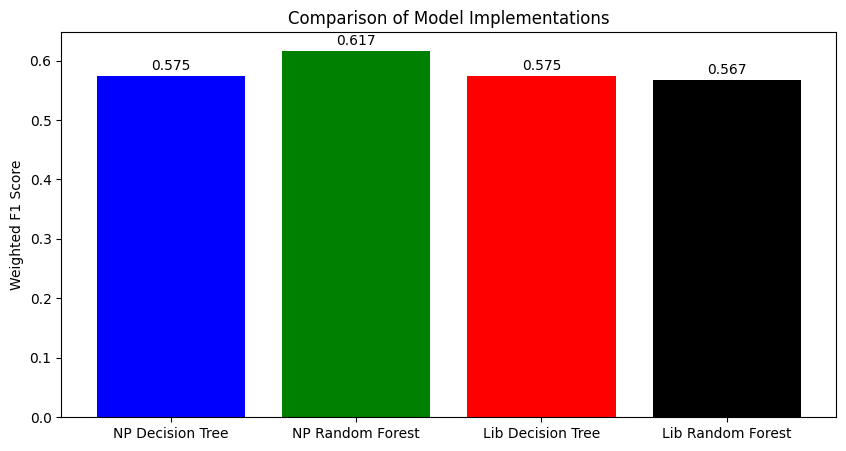


--- Library Random Forest Classification Report ---
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         8
           5       0.70      0.75      0.73       101
           6       0.52      0.62      0.57        93
           7       0.40      0.24      0.30        34
           8       0.00      0.00      0.00         3

    accuracy                           0.59       240
   macro avg       0.27      0.27      0.26       240
weighted avg       0.55      0.59      0.57       240



In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Red Wine Lib
lr_dt = DecisionTreeClassifier(max_depth=5).fit(Xr_tr, yr_tr)
lr_rf = RandomForestClassifier(n_estimators=15, max_depth=7).fit(Xr_tr, yr_tr)
# White Wine Lib
lw_dt = DecisionTreeClassifier(max_depth=5).fit(Xw_tr, yw_tr)
lw_rf = RandomForestClassifier(n_estimators=15, max_depth=7).fit(Xw_tr, yw_tr)

# All Test F1
res_r = [f1_score(yr_te, pr_dt, average='weighted'), f1_score(yr_te, pr_rf, average='weighted'),
         f1_score(yr_te, lr_dt.predict(Xr_te), average='weighted'), f1_score(yr_te, lr_rf.predict(Xr_te), average='weighted')]
res_w = [f1_score(yw_te, pw_dt, average='weighted'), f1_score(yw_te, pw_rf, average='weighted'),
         f1_score(yw_te, lw_dt.predict(Xw_te), average='weighted'), f1_score(yw_te, lw_rf.predict(Xw_te), average='weighted')]

lbl = ['NP DT', 'NP RF', 'Lib DT', 'Lib RF']
x = np.arange(len(lbl))

plt.bar(x - 0.2, res_r, 0.4, label='Red', color='red')
plt.bar(x + 0.2, res_w, 0.4, label='White', color='blue')
plt.xticks(x, lbl); plt.ylabel("F1 Score"); plt.title("Final Comparison (Red vs White)"); plt.legend(); plt.show()

print("--- F1 Score Summary ---")
for i, name in enumerate(lbl):
    print(f"{name:15} | Red: {res_r[i]:.4f} | White: {res_w[i]:.4f}")